In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gget
from tqdm import tqdm
from scipy.stats import ttest_ind
import matplotlib.colors as mcolors
import os
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import rapids_singlecell as rsc
import anndata as an
import scanpy as sc
import scvi
from cuml import UMAP

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Load gene sets

In [2]:
# load tfs so I got 'em
fpath = "../../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:5]

['ZNF354C', 'KLF12', 'ZNF143', 'ZIC2', 'ZNF274']

In [3]:
fpath = "../../../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)
mdf['val'] = 1
print(mdf.head().to_string(index=False))

gene_name         cell_type  is_tf  source    category  val
   TSPAN8 endothelial_cells  False panglao endothelial    1
     KLK1 endothelial_cells  False panglao endothelial    1
   RNASE1 endothelial_cells  False panglao endothelial    1
      LUM endothelial_cells  False panglao endothelial    1
      LOX endothelial_cells  False panglao endothelial    1


In [4]:
mdf_pivot = pd.pivot_table(
    mdf, 
    index=['gene_name',],
    columns=['source', 'category'],
    values='val',
    fill_value=0
)

mdf_pivot.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in mdf_pivot.columns]

mdf_pivot.head()

,panglao_endothelial,panglao_fibroblast,panglao_hematopoietic,tabula_endothelial,tabula_fibroblast,tabula_hematopoietic
gene_name,,,,,,
A2M,1.0,0.0,0.0,1.0,1.0,0.0
ABCA8,1.0,0.0,0.0,0.0,0.0,0.0
ABCB1,0.0,0.0,1.0,0.0,0.0,0.0
ABCG2,1.0,0.0,1.0,0.0,0.0,0.0
ABI3,0.0,1.0,0.0,0.0,0.0,0.0


# Load data

In [5]:
### %%time
dpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/"
alpha = 0.01

clusters = ["C1", "C2", "C3", "C4", "C5"]

df_list = []

for c in clusters:
    fpath = f"{dpath}{c}/output/consensus_network_ncol_.txt"
    df = pd.read_csv(fpath, sep='\t')
    df = df.drop(columns=['source.symbol', 'target.symbol'])
    df['cluster'] = c
    df['sig'] = (df['p-value'] <= alpha)
    df_list.append(df)

df = pd.concat(df_list)
df['pair'] = df['source'] + " → " + df['target']
print(f"{df.shape=}")
print(df.head().to_string())

df.shape=(1044554, 10)
  source   target      MI  pearson  spearman   slope  p-value cluster    sig            pair
0   AATF    ACSL4  0.1007   0.1194    0.1096  0.2190   0.0005      C1   True    AATF → ACSL4
1   AATF  ADAMTS1  0.0917   0.1336    0.1242  0.9153   0.0001      C1   True  AATF → ADAMTS1
2   AATF    ADAT1  0.1066   0.1291    0.1187  0.1188   0.0002      C1   True    AATF → ADAT1
3   AATF  ADIPOR1  0.1037   0.1732    0.1417  0.2654   0.0000      C1   True  AATF → ADIPOR1
4   AATF   ANP32E  0.0888   0.0598    0.0978  0.0922   0.0842      C1  False   AATF → ANP32E


# Simple filtering

In [6]:
print(f"Original edges: {len(df)}")

# Filter source
df = df[~df['source'].str.startswith("MT")]
df = df[~df['source'].str.startswith("RP")]
print(f"After source filter: {len(df)} edges")

# Filter target
df = df[~df['target'].str.startswith("MT")]
df = df[~df['target'].str.startswith("RP")]
print(f"After target filter: {len(df)} edges")

# Reset index
df = df.reset_index(drop=True)
print("Index reset.\n")

# Show preview
print(df.head())


Original edges: 1044554
After source filter: 1040085 edges
After target filter: 997109 edges
Index reset.

  source   target      MI  pearson  spearman   slope  p-value cluster    sig  \
0   AATF    ACSL4  0.1007   0.1194    0.1096  0.2190   0.0005      C1   True   
1   AATF  ADAMTS1  0.0917   0.1336    0.1242  0.9153   0.0001      C1   True   
2   AATF    ADAT1  0.1066   0.1291    0.1187  0.1188   0.0002      C1   True   
3   AATF  ADIPOR1  0.1037   0.1732    0.1417  0.2654   0.0000      C1   True   
4   AATF   ANP32E  0.0888   0.0598    0.0978  0.0922   0.0842      C1  False   

             pair  
0    AATF → ACSL4  
1  AATF → ADAMTS1  
2    AATF → ADAT1  
3  AATF → ADIPOR1  
4   AATF → ANP32E  


# Re-structure

In [7]:
%%time 
pdf = df.copy()

pdf = pd.pivot_table(
    pdf,
    index=['source', 'target'],
    columns=['cluster'],
    values=['MI', 'pearson', 'spearman', 'sig'],
    fill_value=0
)

# Flatten multi-index columns by joining with underscore
pdf.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in pdf.columns]
pdf = pdf.reset_index()
print(f"{pdf.shape=}")
print(pdf.columns)

print(pdf[['source', 'target', 'MI_C1', 'MI_C2', 'MI_C3', 'MI_C4', 'MI_C5',]].head().to_string())

pdf.shape=(873371, 22)
Index(['source', 'target', 'MI_C1', 'MI_C2', 'MI_C3', 'MI_C4', 'MI_C5',
       'pearson_C1', 'pearson_C2', 'pearson_C3', 'pearson_C4', 'pearson_C5',
       'sig_C1', 'sig_C2', 'sig_C3', 'sig_C4', 'sig_C5', 'spearman_C1',
       'spearman_C2', 'spearman_C3', 'spearman_C4', 'spearman_C5'],
      dtype='object')
  source target  MI_C1   MI_C2   MI_C3   MI_C4  MI_C5
0   AATF  ABCF3    0.0  0.0841  0.0000  0.0000    0.0
1   AATF   ABI1    0.0  0.0000  0.1088  0.0000    0.0
2   AATF  ACBD4    0.0  0.0000  0.0689  0.0000    0.0
3   AATF  ACIN1    0.0  0.0000  0.0000  0.0839    0.0
4   AATF   ACO1    0.0  0.0000  0.0000  0.0863    0.0
CPU times: user 758 ms, sys: 345 ms, total: 1.1 s
Wall time: 1.11 s


In [8]:
# add foldchanges

mi_cols = ['MI_C1', 'MI_C2', 'MI_C3', 'MI_C4', 'MI_C5']
fc_columns = []
# Compute log2 fold change of each value vs. mean of other columns in the row
for col in mi_cols:
    others = [c for c in mi_cols if c != col]
    new_column = f'log2FC_{col.replace("MI_", "")}'
    pdf[new_column] = np.log2((pdf[col] + 1) / (pdf[others].mean(axis=1) + 1))
    fc_columns.append(new_column)

print(pdf[['source', 'target'] + fc_columns].head().to_string())

  source target  log2FC_C1  log2FC_C2  log2FC_C3  log2FC_C4  log2FC_C5
0   AATF  ABCF3  -0.030018   0.116498  -0.030018  -0.030018  -0.030018
1   AATF   ABI1  -0.038717  -0.038717   0.148999  -0.038717  -0.038717
2   AATF  ACBD4  -0.024639  -0.024639   0.096127  -0.024639  -0.024639
3   AATF  ACIN1  -0.029948  -0.029948  -0.029948   0.116232  -0.029948
4   AATF   ACO1  -0.030795  -0.030795  -0.030795   0.119423  -0.030795


In [9]:
tdf = pdf.copy()
tdf = tdf[tdf['source'].isin(tf_list)]
tdf = tdf[tdf['target'].isin(tf_list)]
print(f"{tdf.shape=}")
tdf.head()

tdf.shape=(48398, 27)


,source,target,MI_C1,MI_C2,MI_C3,MI_C4,MI_C5,pearson_C1,pearson_C2,pearson_C3,...,spearman_C1,spearman_C2,spearman_C3,spearman_C4,spearman_C5,log2FC_C1,log2FC_C2,log2FC_C3,log2FC_C4,log2FC_C5
664,ADNP,ABL1,0.1479,0.0000,0.0,0.1114,0.0000,0.3373,0.0000,0.0,...,0.2830,0.0000,0.0,0.1385,0.0000,0.159367,-0.090616,-0.090616,0.099997,-0.090616
681,ADNP,AFF4,0.1576,0.1031,0.0,0.0000,0.0000,0.2735,0.1741,0.0,...,0.2456,0.1852,0.0,0.0000,0.0000,0.174423,0.085813,-0.091090,-0.091090,-0.091090
683,ADNP,AGMAT,0.0000,0.0000,0.0,0.0000,0.0718,0.0000,0.0000,0.0,...,0.0000,0.0000,0.0,0.0000,0.0375,-0.025667,-0.025667,-0.025667,-0.025667,0.100036
684,ADNP,AHCTF1,0.0000,0.1055,0.0,0.0000,0.0000,0.0000,0.1923,0.0,...,0.0000,0.1513,0.0,0.0000,0.0000,-0.037558,0.144699,-0.037558,-0.037558,-0.037558
685,ADNP,AHDC1,0.0000,0.0000,0.0,0.0979,0.0000,0.0000,0.0000,0.0,...,0.0000,0.0000,0.0,0.1446,0.0000,-0.034885,-0.034885,-0.034885,0.134747,-0.034885


# Build graph

In [10]:
%%time
G = nx.from_pandas_edgelist(
    # tdf, # could be pdf for all interactions
    pdf, # could be tdf for tf-tf interactions
    edge_attr=True,
    create_using=nx.DiGraph(),
)

nx.set_node_attributes(G, {n: True for n in tf_list if n in G}, 'is_tf')

attrs = nx.get_node_attributes(G, 'is_tf')
n_true = sum(attrs.values())
n_total = G.number_of_nodes()

print(f"{n_true} / {n_total} nodes are TFs")

print(G)

1484 / 21157 nodes are TFs
DiGraph with 21157 nodes and 873371 edges
CPU times: user 4.23 s, sys: 475 ms, total: 4.71 s
Wall time: 4.72 s


# Get Expression Data

In [11]:
%%time

# File path
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
print(f"Loading AnnData from: {fpath}")
adata = sc.read_h5ad(fpath)

# Use log-normalized layer
adata.X = adata.layers['log_norm'].copy()
print("Set `adata.X` to 'log_norm' layer.")

# Filter genes to match nodes in the graph
nodes = list(G.nodes())
print(f"Filtering genes to {len(nodes)} nodes in the graph...")
adata = adata[:, nodes].copy()

# Extract expression matrix and cluster labels
expr_df = adata.to_df()
clusters = adata.obs['cluster_str']
print(f"Expression matrix shape: {expr_df.shape}")
print(f"Number of unique clusters: {clusters.nunique()}")

# Compute mean and non-zero percentage per gene per cluster
stats = {}
for clust in clusters.unique():
    print(f"Processing cluster: {clust}")
    mask = clusters == clust
    X_cluster = expr_df[mask]
    stats[f'mean_{clust}'] = X_cluster.mean()
    stats[f'nonzero_pct_{clust}'] = (X_cluster > 0).sum() / X_cluster.shape[0] * 100

# Combine stats into a single DataFrame
X = pd.DataFrame(stats)
X.index.name = 'gene'

# Convert the DataFrame to a dict-of-dicts: {node: {attr_name: value, ...}, ...}
attr_dict = X.to_dict(orient='index')
nx.set_node_attributes(G, attr_dict)

print(f"Final stats shape: {X.shape}")
print("Columns in output:")
print(X.columns.tolist())
print(X.head().to_string())

Loading AnnData from: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad
Set `adata.X` to 'log_norm' layer.
Filtering genes to 21157 nodes in the graph...
Expression matrix shape: (15867, 21157)
Number of unique clusters: 5
Processing cluster: C3
Processing cluster: C4
Processing cluster: C5
Processing cluster: C2
Processing cluster: C1
Final stats shape: (21157, 10)
Columns in output:
['mean_C3', 'nonzero_pct_C3', 'mean_C4', 'nonzero_pct_C4', 'mean_C5', 'nonzero_pct_C5', 'mean_C2', 'nonzero_pct_C2', 'mean_C1', 'nonzero_pct_C1']
        mean_C3  nonzero_pct_C3   mean_C4  nonzero_pct_C4   mean_C5  nonzero_pct_C5   mean_C2  nonzero_pct_C2   mean_C1  nonzero_pct_C1
gene                                                                                                                                   
AATF   0.135796       20.504253  0.218729       37.992750  0.160086       22.429907  0.117485       17.143948  0.124763       22.302158
ABCF3  0.101

# Group-specific centralities

In [12]:
%%time

centrality_results = []

for cluster in df['cluster'].unique():
    weight = f"MI_{cluster}"
    
    # Compute eigenvector centrality with weight
    ec = nx.eigenvector_centrality(G, max_iter=1000, weight=weight)
    
    # Convert to DataFrame
    ec_df = pd.DataFrame.from_dict(ec, orient='index', columns=['eigenvector_centrality'])
    ec_df['gene_name'] = ec_df.index
    ec_df['cluster'] = cluster
    
    centrality_results.append(ec_df.reset_index(drop=True))

# Combine all cluster-specific centralities
final_df = pd.concat(centrality_results, ignore_index=True)

# Optional: reorder columns
final_df = final_df[['gene_name', 'cluster', 'eigenvector_centrality']]
final_df.head()

CPU times: user 43 s, sys: 132 ms, total: 43.2 s
Wall time: 43.3 s


,gene_name,cluster,eigenvector_centrality
0,AATF,C1,0.001522
1,ABCF3,C1,0.000252
2,ABI1,C1,0.021481
3,ACBD4,C1,0.000006
4,ACIN1,C1,0.011499


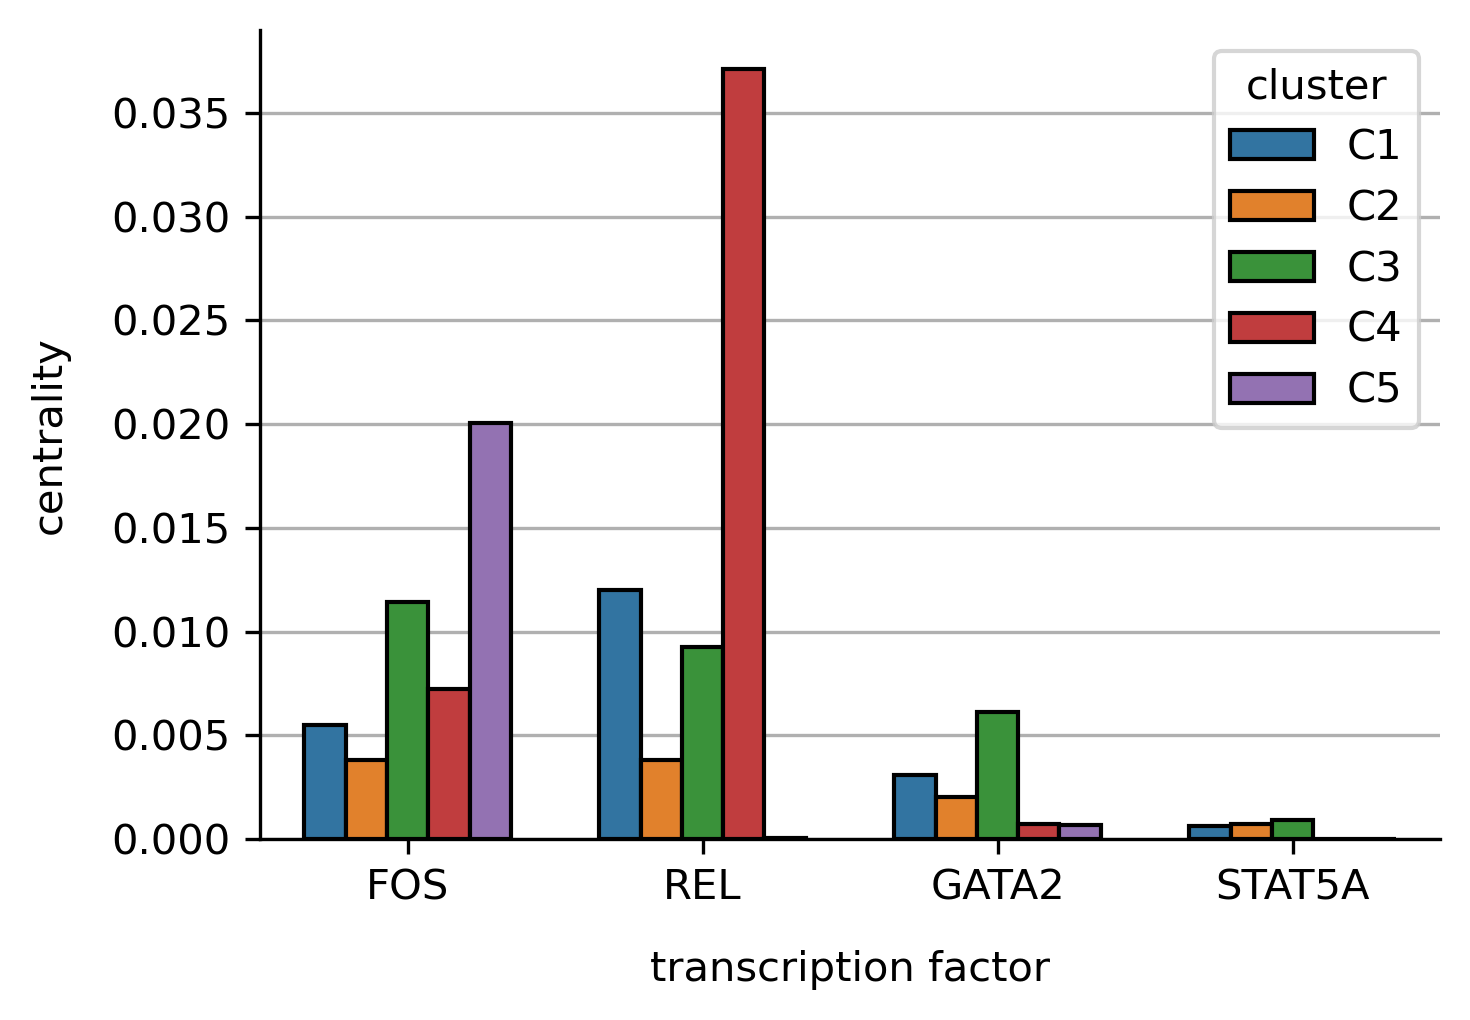

In [13]:
tf_recipe = ['GATA2', 'REL', 'STAT5A', 'FOS']
plot_df = final_df.copy()
plot_df = plot_df[plot_df['gene_name'].isin(tf_recipe)]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (5, 3.5)

ax = sns.barplot(
    data=plot_df,
    x='gene_name',
    y='eigenvector_centrality',
    hue='cluster',
    edgecolor='k',
    zorder=4,
    width=0.7,
)

# Labeling
ax.set_xlabel("transcription factor", labelpad=10)
ax.set_ylabel("centrality", labelpad=10)
ax.yaxis.grid(True, zorder=1)

# Draw legend last with higher zorder
legend = ax.legend(title="cluster", frameon=True)
legend.set_zorder(3)
sns.despine()

# Optional: Tighter layout
plt.tight_layout()
plt.show()

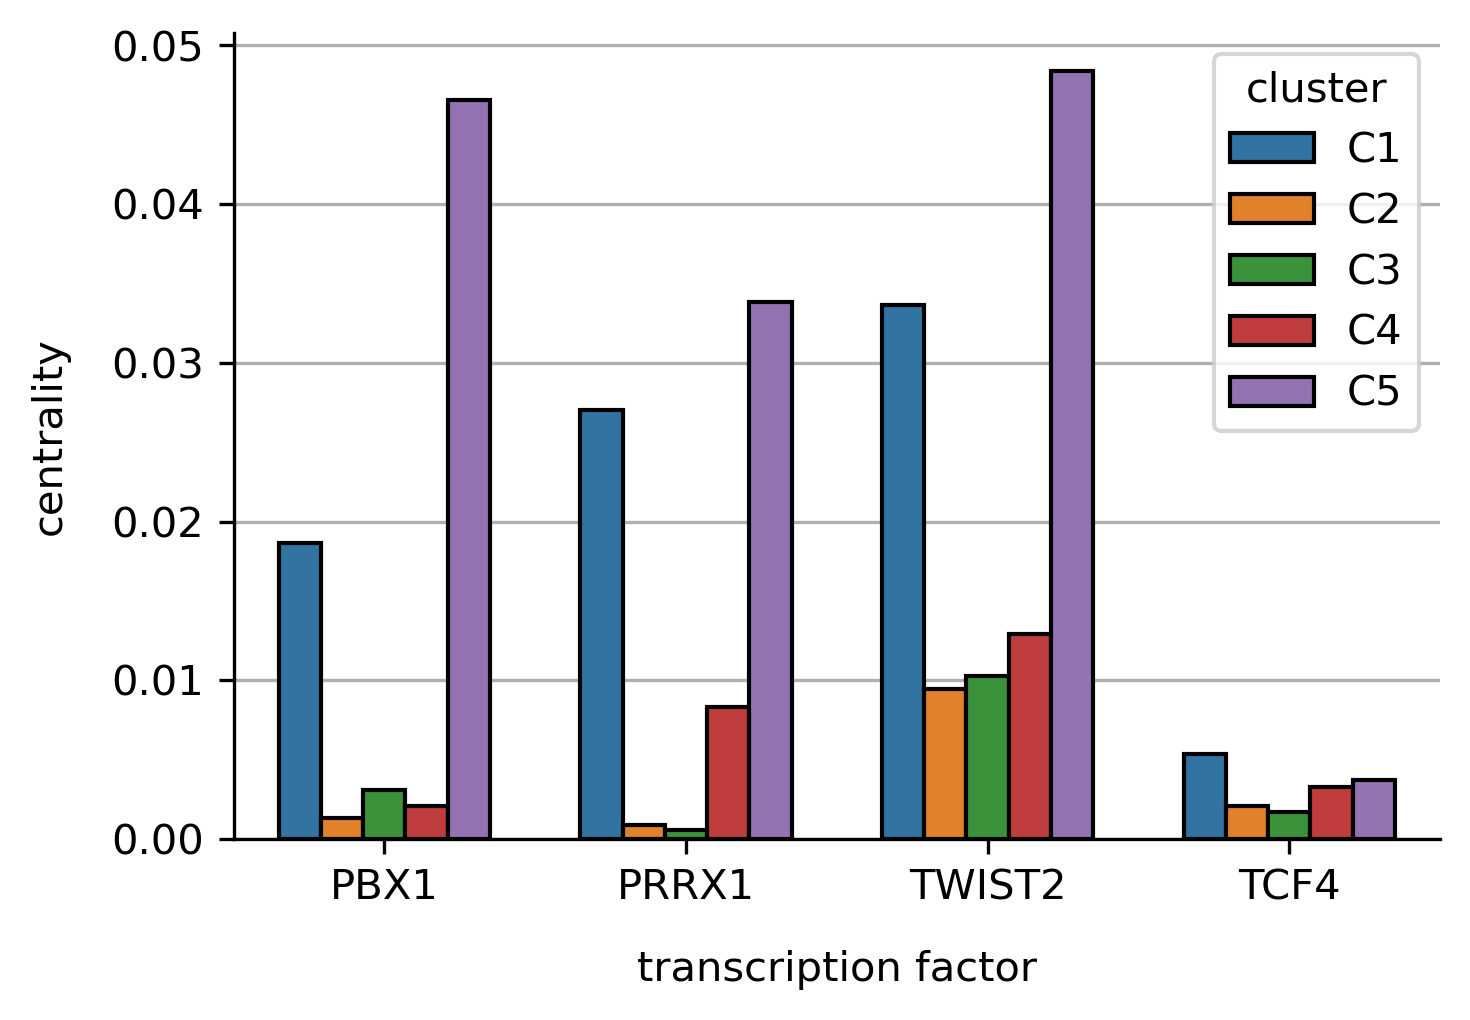

In [14]:
tf_recipe = ['PRRX1', 'TWIST2', 'PBX1', 'TCF4']
plot_df = final_df.copy()
plot_df = plot_df[plot_df['gene_name'].isin(tf_recipe)]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (5, 3.5)

ax = sns.barplot(
    data=plot_df,
    x='gene_name',
    y='eigenvector_centrality',
    hue='cluster',
    edgecolor='k',
    zorder=4,
    width=0.7,
)

# Labeling
ax.set_xlabel("transcription factor", labelpad=10)
ax.set_ylabel("centrality", labelpad=10)
ax.yaxis.grid(True, zorder=1)

# Draw legend last with higher zorder
legend = ax.legend(title="cluster", frameon=True)
legend.set_zorder(3)
sns.despine()

# Optional: Tighter layout
plt.tight_layout()
plt.show()

15:28:35 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        
15:28:35 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        



 ======== C1 ======== 
                                                             path_name  adj_p_val        genes
         negative regulation of smooth muscle contraction (GO:0045986)   0.001906 DOCK5,KCNMA1
                         regulation of cell-cell adhesion (GO:0022407)   0.059104   MAGI1,PTK2
regulation of substrate adhesion-dependent cell spreading (GO:1900024)   0.059104   DOCK5,PTK2
                  regulation of epithelial cell migration (GO:0010632)   0.059104   DOCK5,PTK2
                     positive regulation of cell adhesion (GO:0045785)   0.090893  MAGI1,ZFHX3


15:28:36 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        



 ======== C2 ======== 
                                                        path_name  adj_p_val                              genes
                extracellular structure organization (GO:0043062)   0.000324 ITGB1,COL1A1,SPARC,COL1A2,SERPINE1
       external encapsulating structure organization (GO:0045229)   0.000324 ITGB1,COL1A1,SPARC,COL1A2,SERPINE1
                   extracellular matrix organization (GO:0030198)   0.000916 ITGB1,COL1A1,SPARC,COL1A2,SERPINE1
positive regulation of receptor-mediated endocytosis (GO:0048260)   0.000916                 ANXA2,SERPINE1,B2M
             positive regulation of receptor binding (GO:1900122)   0.000944                          ANXA2,B2M


15:28:36 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        



 ======== C3 ======== 
                                                     path_name  adj_p_val                        genes
          positive regulation of receptor binding (GO:1900122)   0.002175                    ANXA2,B2M
                           membrane raft assembly (GO:0001765)   0.002175                ANXA2,S100A10
                         neutrophil degranulation (GO:0043312)   0.005048 CSTB,ANXA2,SRP14,B2M,S100A11
neutrophil activation involved in immune response (GO:0002283)   0.005048 CSTB,ANXA2,SRP14,B2M,S100A11
                     neutrophil mediated immunity (GO:0002446)   0.005048 CSTB,ANXA2,SRP14,B2M,S100A11


15:28:36 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        



 ======== C4 ======== 
                                                   path_name    adj_p_val                          genes
                   defense response to symbiont (GO:0140546) 2.740774e-09 IFITM3,IFI16,MX1,IFI6,ISG15...
         cellular response to type I interferon (GO:0071357) 2.740774e-09 IFITM3,MX1,IFI6,ISG15,IFIT1...
            type I interferon signaling pathway (GO:0060337) 2.740774e-09 IFITM3,MX1,IFI6,ISG15,IFIT1...
                      defense response to virus (GO:0051607) 2.740774e-09 IFITM3,IFI16,MX1,IFI6,ISG15...
negative regulation of viral genome replication (GO:0045071) 1.105900e-07   IFITM3,IFI16,MX1,ISG15,IFIT1

 ======== C5 ======== 
                                                   path_name  adj_p_val                     genes
                           response to cytokine (GO:0034097)   0.002579 IFITM3,IFITM1,ISG15,PRKCA
negative regulation of viral genome replication (GO:0045071)   0.002579       IFITM3,IFITM1,ISG15
         cellular response t

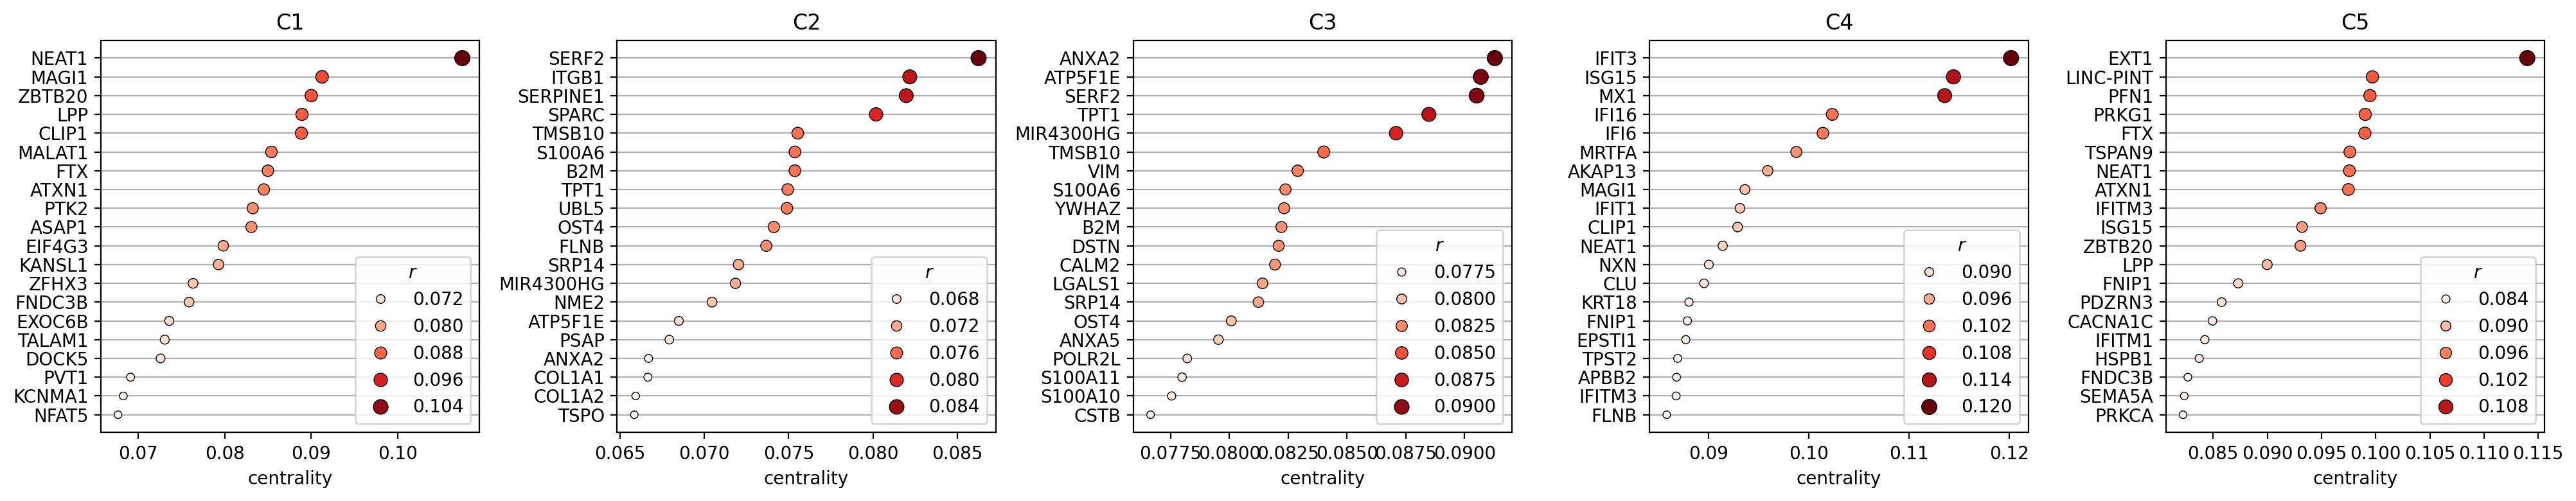

In [15]:
plot_df = final_df.copy()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 20, 4
fig, axes = plt.subplots(1, 5)

for i, (group_name, group) in enumerate(plot_df.groupby('cluster')):
    group = group.sort_values('eigenvector_centrality', ascending=False)

    sns.scatterplot(
        data=group.head(20),
        x='eigenvector_centrality',
        y='gene_name',
        hue='eigenvector_centrality',
        size='eigenvector_centrality',
        palette='Reds',
        ec='k',
        lw=0.5,
        ax=axes[i],
        zorder=5,
    )
    axes[i].set_ylabel("")
    axes[i].set_xlabel("centrality")
    axes[i].set_title(group_name)
    axes[i].yaxis.grid(True, zorder=0)
    sns.move_legend(
        axes[i],
        loc='lower right',
        title=r'$r$', 
    )

    edf = gget.enrichr(group['gene_name'].head(20), database='ontology')
    edf['genes'] = edf['overlapping_genes'].apply(
        lambda x: ",".join(x[:5]) + ("..." if len(x) > 5 else "")
    )
    print(f"\n ======== {group_name} ======== ")
    print(edf[['path_name', 'adj_p_val', 'genes']].head().to_string(index=False))
    
    
plt.tight_layout()

In [16]:
plot_df = final_df.copy()
plot_df = pd.pivot_table(
    plot_df,
    index='gene_name',
    columns='cluster',
    values='eigenvector_centrality',
)

# ranks to mitigate scaling issues
plot_df = plot_df.rank(
    axis=0, 
    ascending=True,
    method='min',
    pct=True,
)

n = 10  # Number of top genes per cluster

for col in plot_df.columns:
    print(f"\nCluster: {col}")

    # Most central genes overall
    top_genes_col = plot_df[col].nsmallest(n).index.to_list()
    print("\tMost central genes:", ", ".join(top_genes_col))

    # Most central genes by cell type
    for cell_type, group in mdf.groupby('category'):
        mask = plot_df.index.isin(group['gene_name'])
        top_by_type = plot_df[mask][col].nsmallest(n).index.to_list()
        print(f"\tMost central {cell_type} genes:", ", ".join(top_by_type))


Cluster: C1
	Most central genes: AANAT, ABCA13, ABCB1, ABRA, ACSM3, ACTA1, ACVR2B-AS1, ADAMTS9, ADGRE2, ADH1A
	Most central endothelial genes: ADAMTS9, ADH1A, CYTL1, DLL4, ECSCR, FGD5, GFAP, IL1RL1, LYVE1, MRC1
	Most central fibroblast genes: FRZB, HGF, IL1RL1, SERPINB10, IL34, NFATC1, TNFAIP6, PRB3, HTRA3, APOE
	Most central hematopoietic genes: ABCB1, APOA1, CR1L, FGD5, HGF, KLRF1, LMO2, LYL1, LYVE1, MRC1

Cluster: C2
	Most central genes: AANAT, ABCA13, ABCB1, ABCC9, ACOT12, ACVR2B-AS1, ADAM23, ADAMTS9, ADAMTS9-AS2, ADCY5
	Most central endothelial genes: ADAMTS9, CLEC14A, CLEC1A, CPE, CSF3, CYTL1, CYYR1, DLL4, ECSCR, FABP4
	Most central fibroblast genes: ANGPTL7, CLEC14A, CXCL14, FABP4, FMOD, FNDC1, FRZB, IL1RL1, PENK, PRG4
	Most central hematopoietic genes: ABCB1, ALAS2, CFP, CLEC14A, GYPB, KIT, KLRF1, LYVE1, MRC1, MYCT1

Cluster: C3
	Most central genes: AANAT, AARD, AATK, ABCA12, ABCC2, ABCC9, ABHD3, ABHD8, ACADS, ACMSD
	Most central endothelial genes: AQP1, BMP4, C1QTNF5, CDKN1C,

# All TFs

filter 1 plot_df.shape=(1484, 5)
filter 2 plot_df.shape=(58, 5)


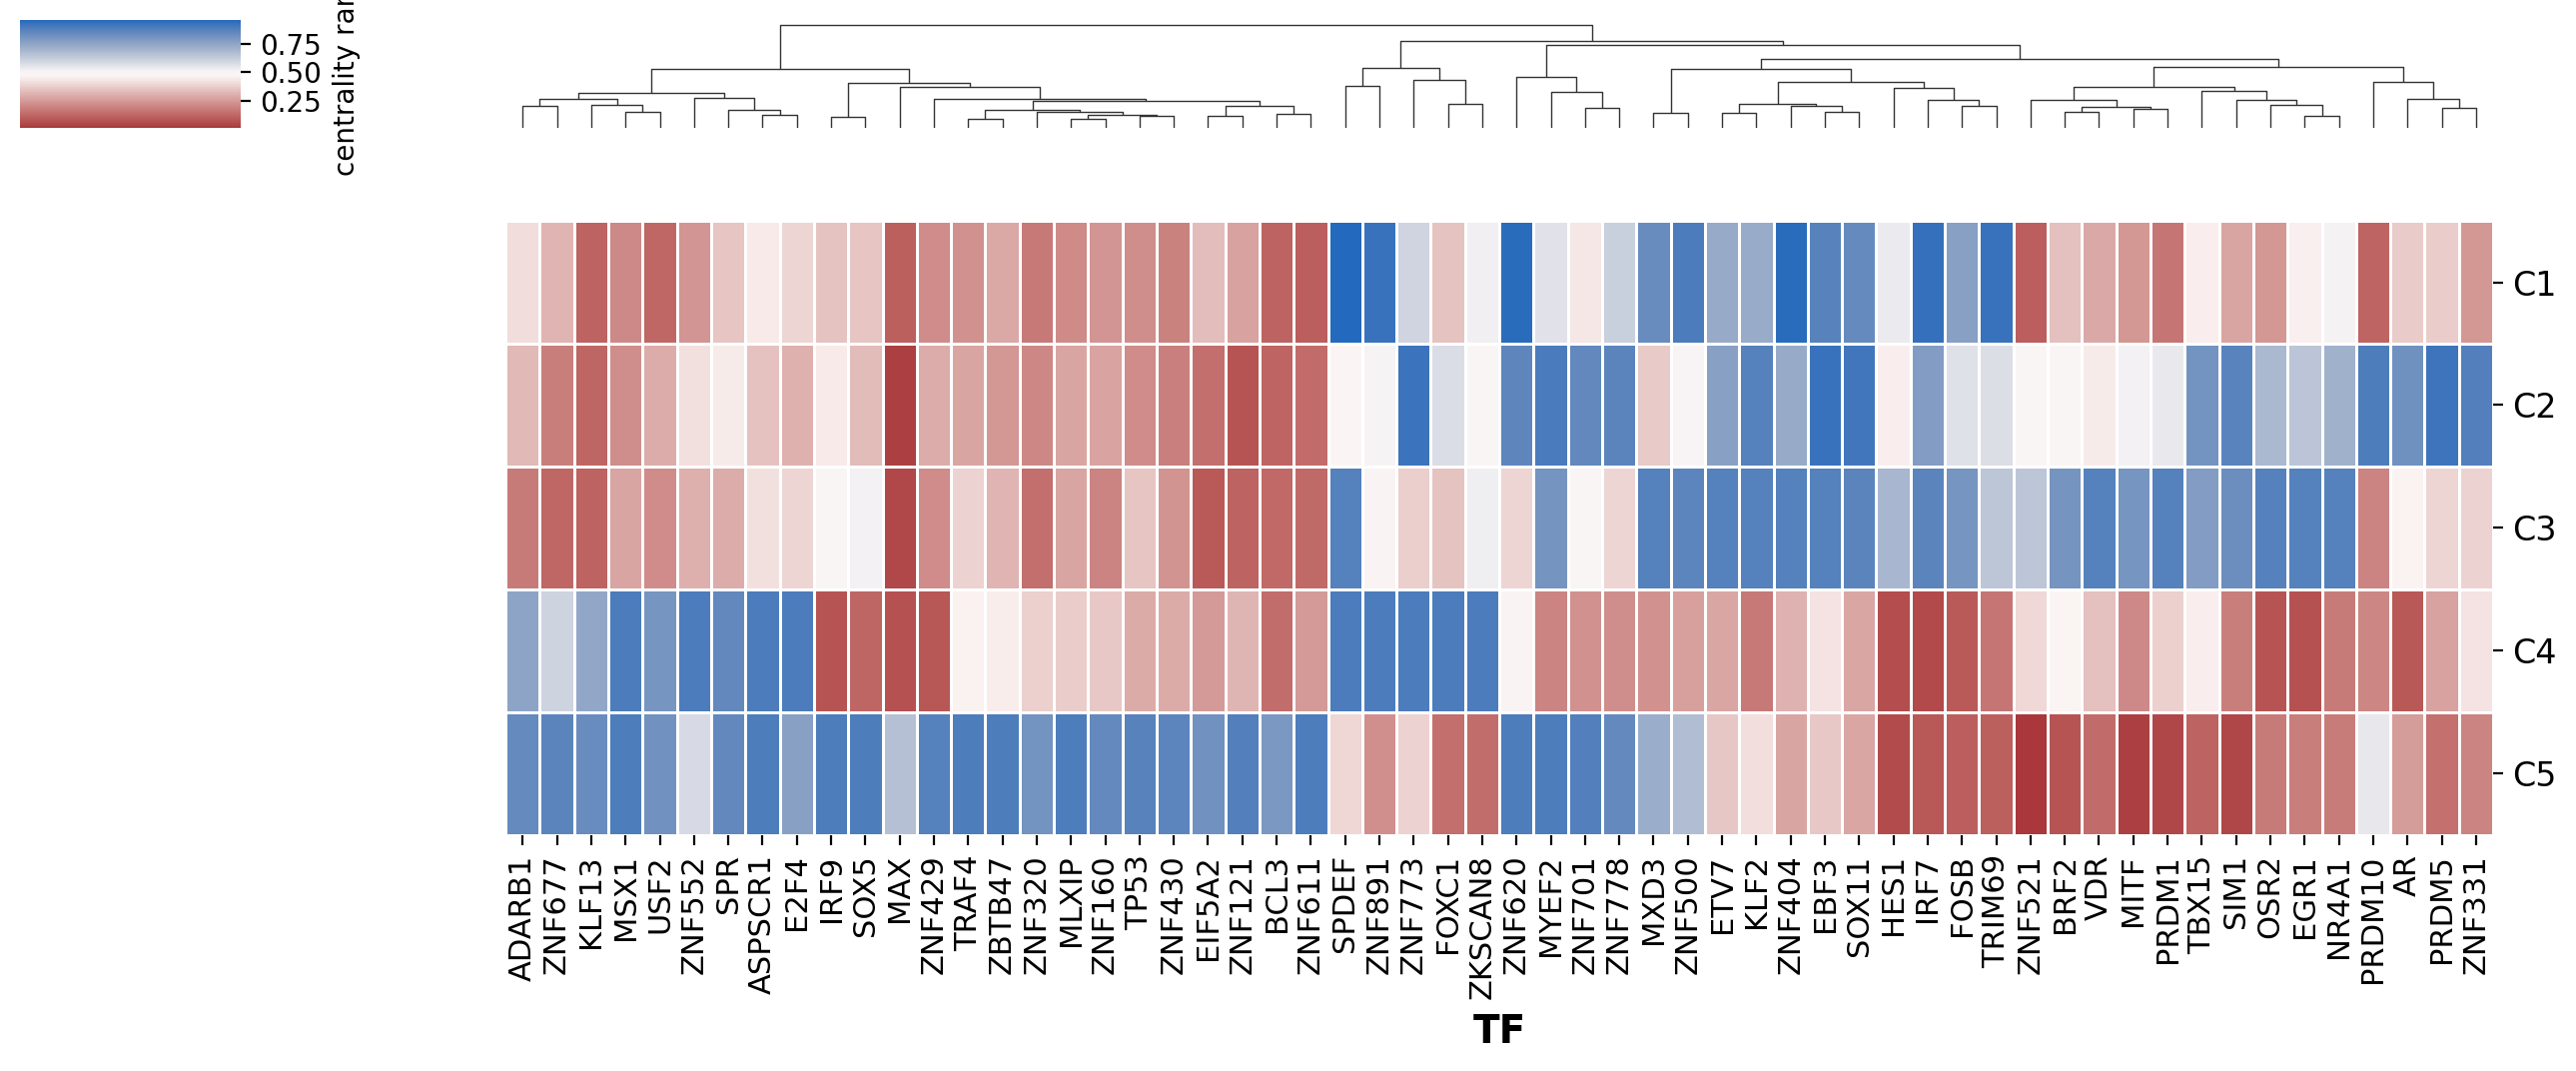

In [17]:
plot_df = final_df.copy()
plot_df = pd.pivot_table(
    plot_df,
    index='gene_name',
    columns='cluster',
    values='eigenvector_centrality',
)

# ranks to mitigate scaling issues
plot_df = plot_df.rank(
    axis=0, 
    ascending=False,
    method='min',
    pct=True,
)

plot_df = plot_df[plot_df.index.isin(tf_list)]
print(f"filter 1 {plot_df.shape=}")
plot_df = plot_df[plot_df.std(axis=1) > 0.26]
print(f"filter 2 {plot_df.shape=}")

g = sns.clustermap(
    data=plot_df.T,
    cmap="vlag_r",                          # Perceptually uniform, suitable for rank data
    linewidths=0.4,                         # Thin grid lines
    linecolor='white',
    figsize=(13, 5.5),                         # Large, readable
    row_cluster=False,
    cbar_kws={"label": "centrality rank"},
    xticklabels=True,                       # Show gene names
    yticklabels=True,                       # Show cluster names
    method='average',                       # Hierarchical clustering method
    metric='euclidean',                     # Clustering metric
    z_score=None,                           # No standardization; already normalized
    dendrogram_ratio=(0.1, 0.15),          # Reduce dendrogram size
    colors_ratio=0.1,                       # Thinner color bars
)

# Move the colorbar to the right (increase the left coordinate)
if g.cax is not None:
    box = g.cax.get_position()
    # Arguments: [left, bottom, width, height]
    g.cax.set_position([box.x0 + 0.08, box.y0, box.width, box.height])


# Clean up tick labels
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=11)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)

# Add labels and title
g.ax_heatmap.set_xlabel("TF", labelpad=5, fontsize=14, weight='bold')
g.ax_heatmap.set_ylabel("", labelpad=5, fontsize=14)

# Tight layout for clean export
plt.tight_layout()
plt.show()

# Cell type TFs

['endothelial' 'fibroblast' 'hematopoietic']
Unfiltered gdf.shape=(166, 2)
Filtered gdf.shape=(96, 2)
    gene_name     category
508     SRRM3  endothelial
522     SALL1  endothelial
526     FOXL2  endothelial
527     MEIS3  endothelial
538     PPARD  endothelial
cell type specific TFs gdf.shape=(96, 2)
category
endothelial      38
hematopoietic    36
fibroblast       22
filter 1 plot_df.shape=(71, 5)
filter 2 plot_df.shape=(56, 5)


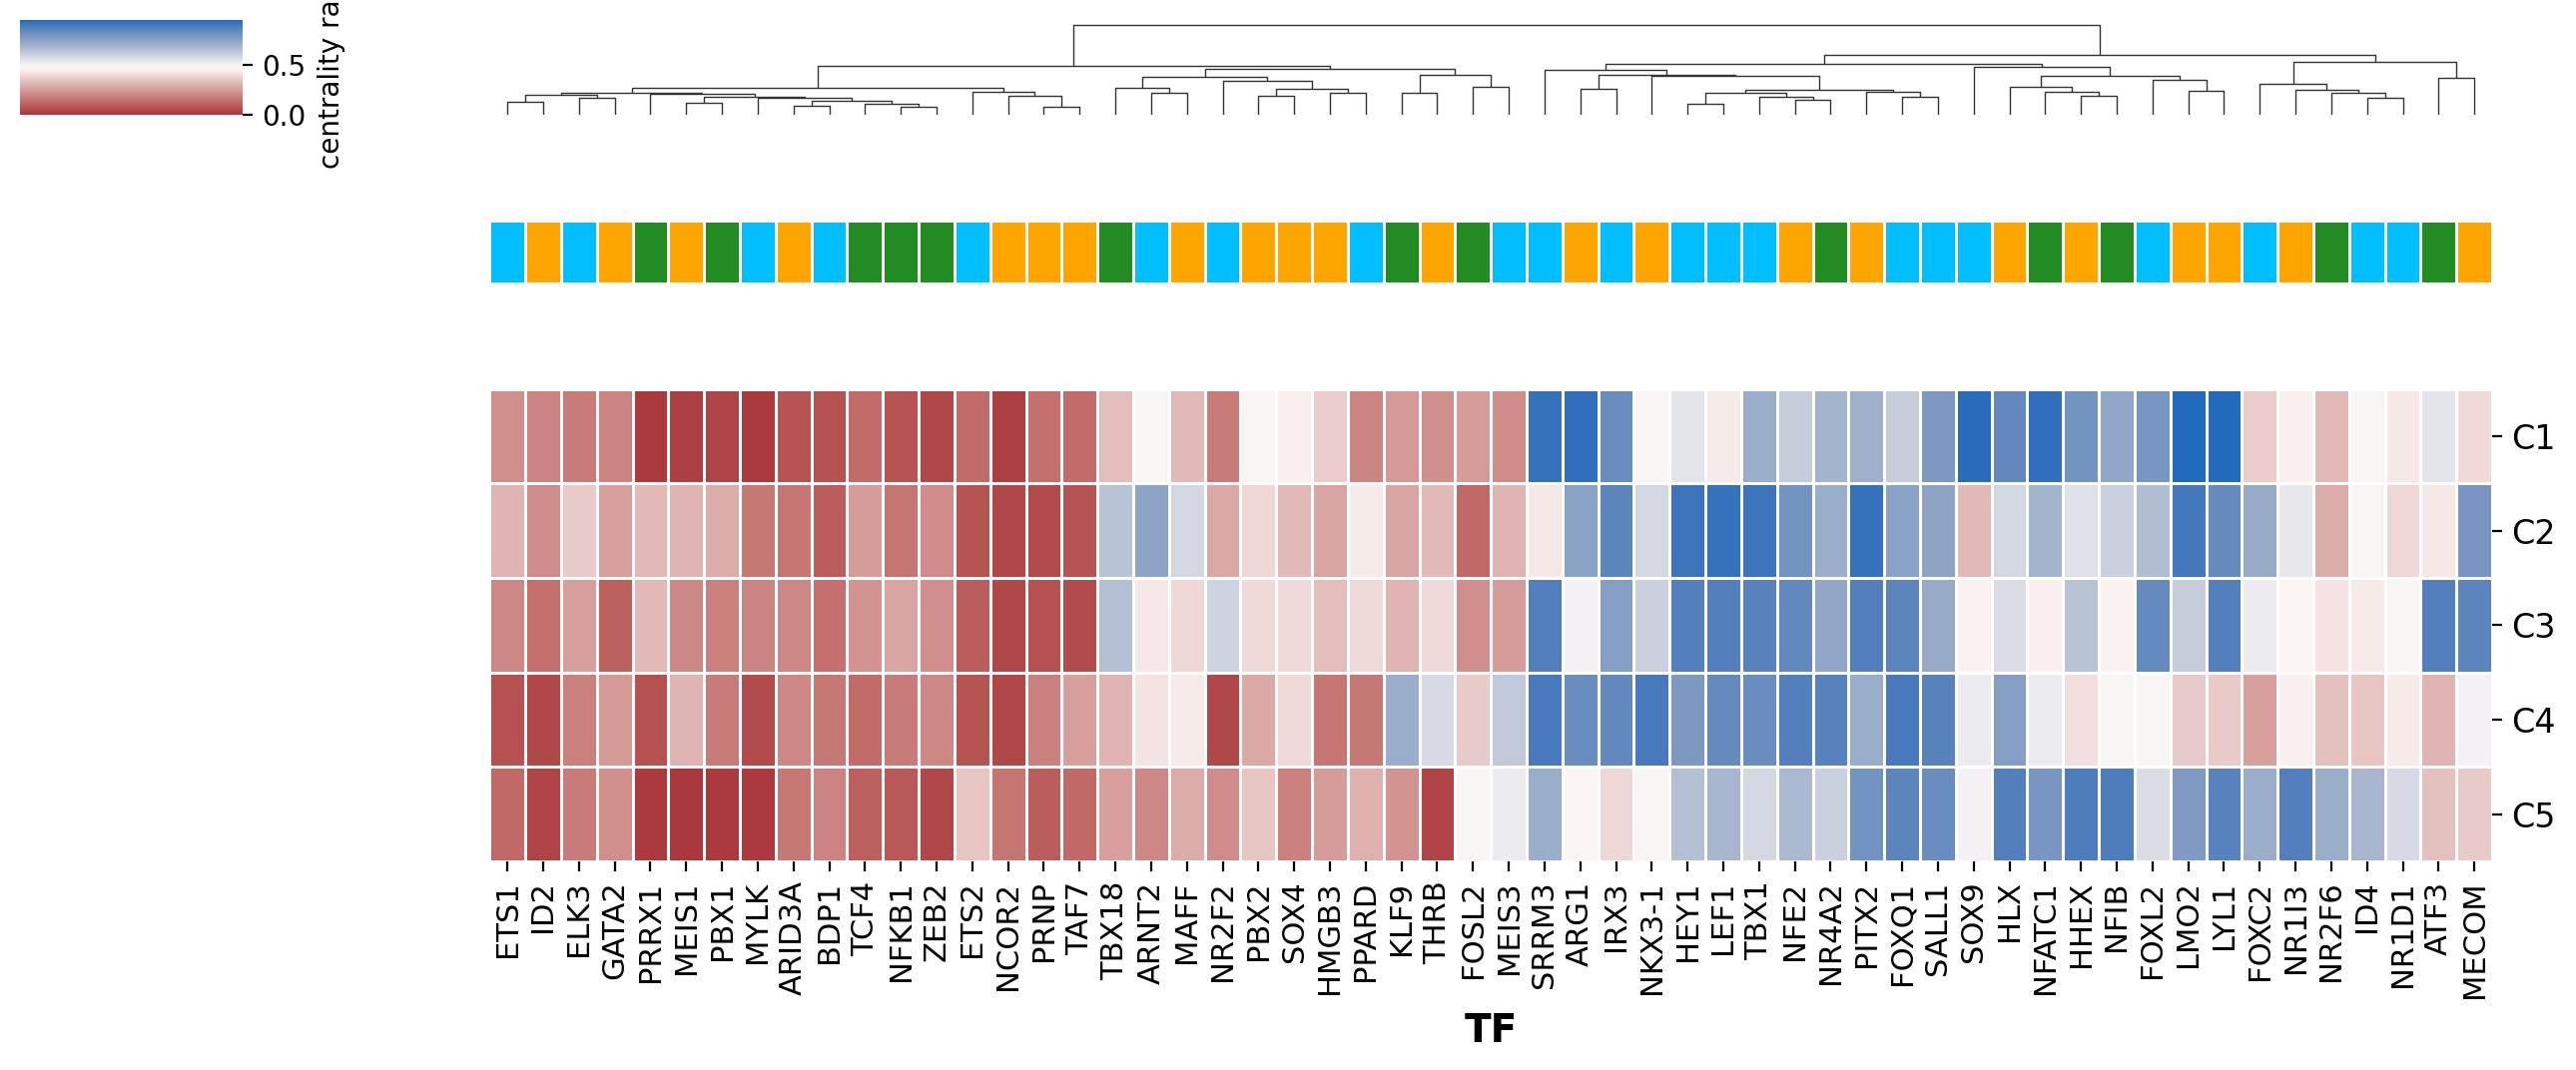

In [18]:
gdf = mdf[mdf['is_tf']][['gene_name', 'category']].drop_duplicates()
gdf = gdf.sort_values('category')
print(gdf['category'].unique())
print(f"Unfiltered {gdf.shape=}")

# drop non-unique genes
unique_genes = gdf['gene_name'].value_counts()
unique_only = unique_genes[unique_genes == 1].index
gdf = gdf[gdf['gene_name'].isin(unique_only)]
print(f"Filtered {gdf.shape=}")
print(gdf.head().to_string())

type_map = dict(zip(gdf['gene_name'].values, gdf['category'].values))

print(f"cell type specific TFs {gdf.shape=}")
print(gdf['category'].value_counts().to_string())

plot_df = final_df.copy()
plot_df = pd.pivot_table(
    plot_df,
    index='gene_name',
    columns='cluster',
    values='eigenvector_centrality',
)

# ranks to mitigate scaling issues
plot_df = plot_df.rank(
    axis=0, 
    ascending=False,
    method='min',
    pct=True,
)

plot_df = plot_df[plot_df.index.isin(gdf['gene_name'].unique())]
print(f"filter 1 {plot_df.shape=}")
plot_df = plot_df[plot_df.std(axis=1) > 0.05]
print(f"filter 2 {plot_df.shape=}")

plot_df = plot_df.round(2)


color_dict = {
    'endothelial': 'deepskyblue',    # blue
    'fibroblast':   'forestgreen',    # red
    'hematopoietic': 'orange',   # green
} 

row_colors = plot_df.index.map(type_map)
row_colors = row_colors.map(color_dict)

g = sns.clustermap(
    data=plot_df.T,
    cmap="vlag_r",                          # Perceptually uniform, suitable for rank data
    linewidths=0.4,                         # Thin grid lines
    linecolor='white',
    col_colors=row_colors,
    row_cluster=False,
    figsize=(13, 5.5),                         # Large, readable
    cbar_kws={"label": "centrality rank"},
    xticklabels=True,                       # Show gene names
    yticklabels=True,                       # Show cluster names
    method='average',                       # Hierarchical clustering method
    metric='euclidean',                     # Clustering metric
    z_score=None,                           # No standardization; already normalized
    dendrogram_ratio=(0.1, 0.15),          # Reduce dendrogram size
    colors_ratio=0.1,                       # Thinner color bars
)

# Move the colorbar to the right (increase the left coordinate)
if g.cax is not None:
    box = g.cax.get_position()
    # Arguments: [left, bottom, width, height]
    g.cax.set_position([box.x0 + 0.08, box.y0, box.width, box.height])


# Clean up tick labels
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=11)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)

# Add labels and title
g.ax_heatmap.set_xlabel("TF", labelpad=5, fontsize=14, weight='bold')
g.ax_heatmap.set_ylabel("", labelpad=5, fontsize=14)

# Tight layout for clean export
plt.tight_layout()
plt.show()

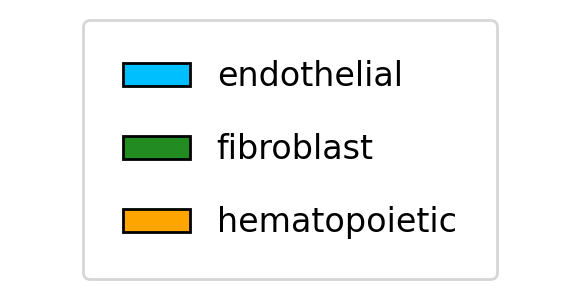

In [19]:
legend_elements = [
    Patch(facecolor=color_dict[name], edgecolor='k', label=name)
    for name in color_dict
]

fig, ax = plt.subplots(figsize=(3, 1.2))
ax.axis('off')  # No axes for legend-only figure

# Place legend in center
ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,
    title='',
    fontsize=12,
    title_fontsize=13,
    ncol=1,
    borderpad=1.2,
    labelspacing=1.2
)

plt.tight_layout()
plt.show()


# Global Graph Distances

            C1          C2          C3          C4          C5
C1      0.0000  58293.1760  46933.6063  45558.8808  43658.8142
C2  58293.1760      0.0000  41367.4913  41577.7816  40368.8846
C3  46933.6063  41367.4913      0.0000  28242.5639  26506.0673
C4  45558.8808  41577.7816  28242.5639      0.0000  22776.7518
C5  43658.8142  40368.8846  26506.0673  22776.7518      0.0000


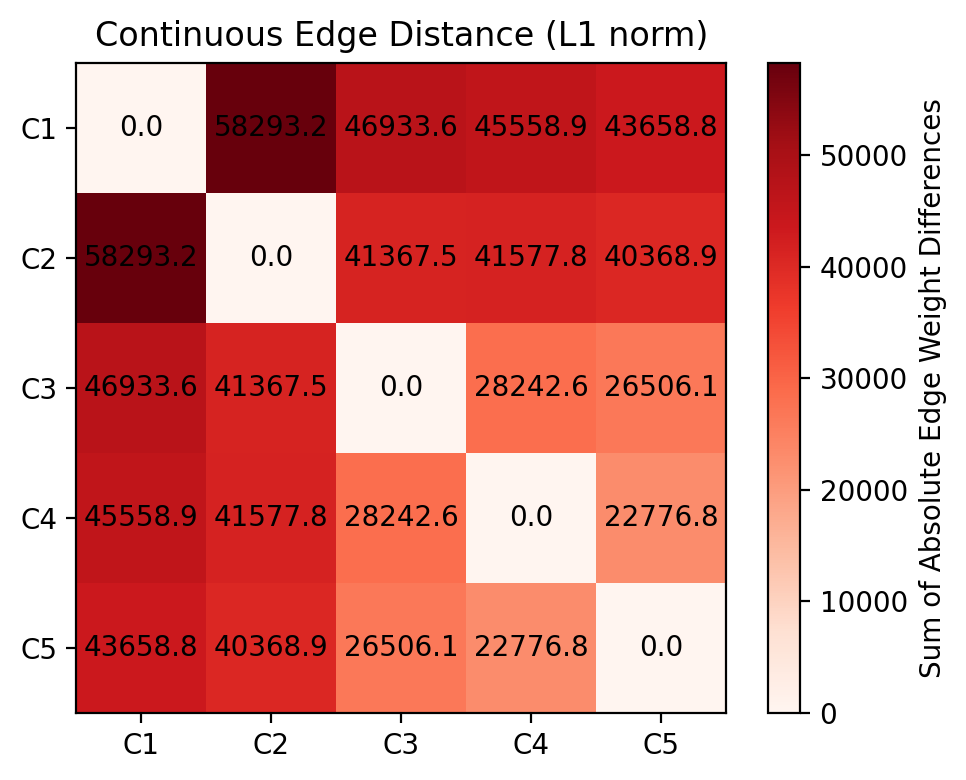

CPU times: user 20.3 s, sys: 1.08 s, total: 21.4 s
Wall time: 21.4 s


In [20]:
%%time
def get_edge_weight_dict(H, cluster):
    attr = f"MI_{cluster}"
    # Edges as (node1, node2): weight
    return {e: H.edges[e].get(attr, 0.0) for e in H.edges()}

clusters = ['C1', 'C2', 'C3', 'C4', 'C5']
continuous_matrix = np.zeros((len(clusters), len(clusters)), dtype=float)

all_edges = set(G.edges())  # All possible edges in the supergraph

for i, c1 in enumerate(clusters):
    for j, c2 in enumerate(clusters):
        if j <= i:
            continue
        w1 = get_edge_weight_dict(G, c1)
        w2 = get_edge_weight_dict(G, c2)
        # For all possible edges, get weights (default 0)
        total = 0.0
        for e in all_edges:
            total += abs(w1.get(e, 0.0) - w2.get(e, 0.0))
        continuous_matrix[i, j] = total
        continuous_matrix[j, i] = total  # symmetric

plot_df = pd.DataFrame(continuous_matrix, index=clusters, columns=clusters)
print(plot_df.to_string())

plt.figure(figsize=(5,4))
im = plt.imshow(plot_df, cmap='Reds')
plt.colorbar(im, label='Sum of Absolute Edge Weight Differences')
plt.xticks(np.arange(len(clusters)), clusters)
plt.yticks(np.arange(len(clusters)), clusters)
plt.title('Continuous Edge Distance (L1 norm)')
for i in range(len(clusters)):
    for j in range(len(clusters)):
        plt.text(j, i, f"{plot_df.iloc[i,j]:.1f}", ha='center', va='center', color='black', fontsize=10)
plt.tight_layout()
plt.show()

# Plot the Fibroblast Network (Global)

Initial gene list from source='panglao', category='fibroblast': 232 genes
Filtered gene list (in graph): 213 genes


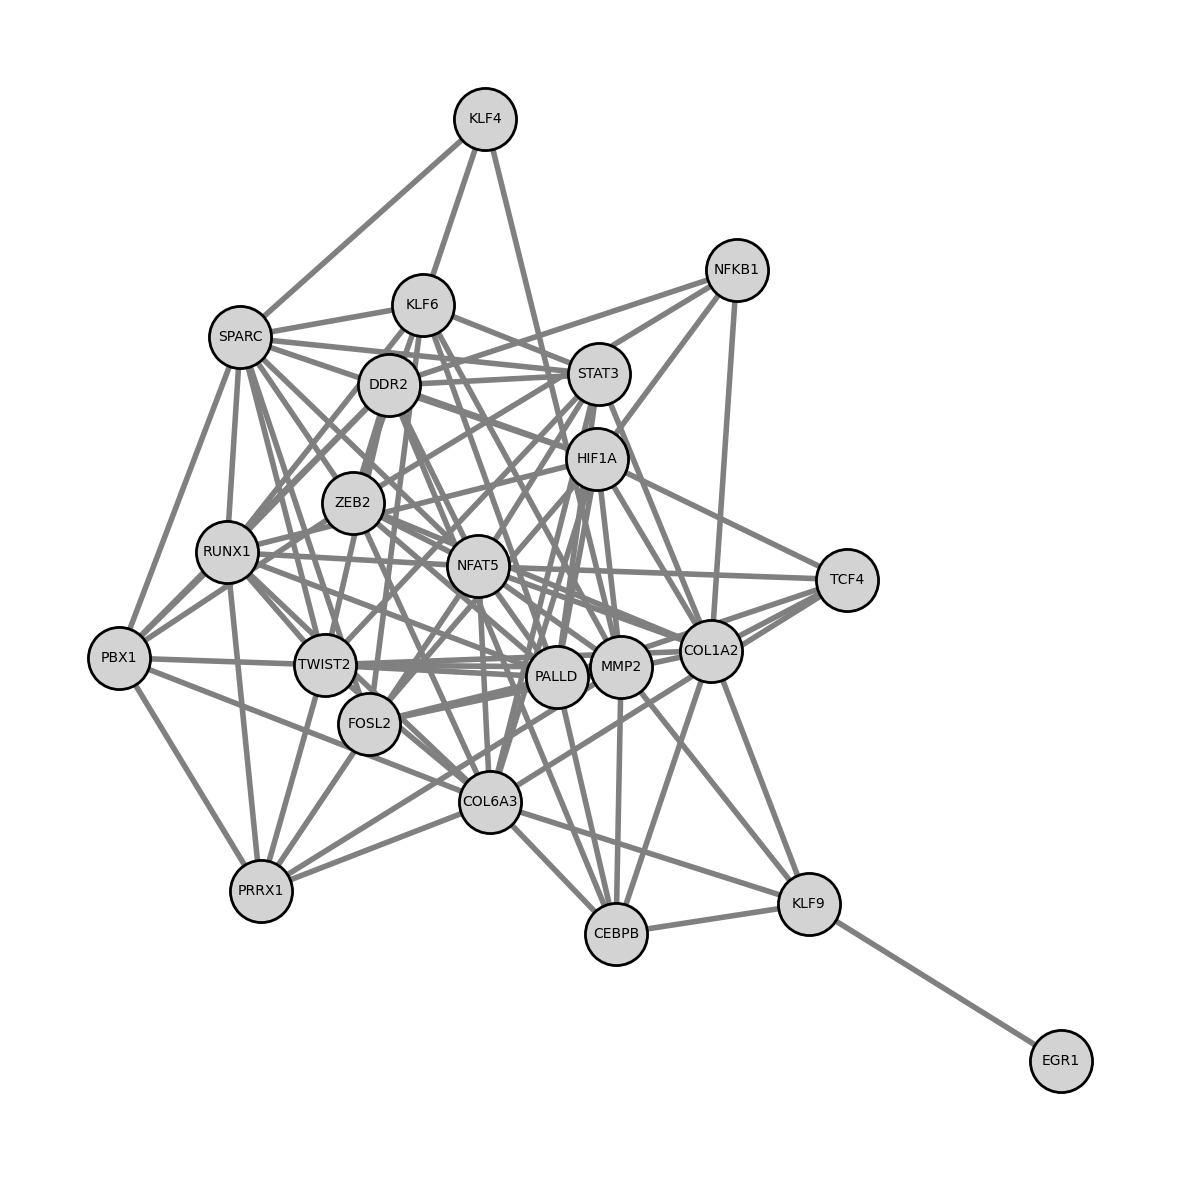

In [21]:
def get_top_degree_subgraph_and_layout(G, mdf, source, category, top_pct=0.10, seed_value=142):
    """
    Returns subgraph H and layout pos for top-degree nodes in specified group.
    """
    # Get gene list
    gene_list = mdf[(mdf['source'] == source) & (mdf['category'] == category)]['gene_name']
    print(f"Initial gene list from source='{source}', category='{category}': {len(gene_list)} genes")

    # Filter to nodes present in graph
    gene_list = [n for n in gene_list if n in G]
    print(f"Filtered gene list (in graph): {len(gene_list)} genes")

    # Subgraph
    H = G.subgraph(gene_list).copy()

    # Compute degree for each node in H
    node_degrees = dict(H.degree())
    n_top = int(np.ceil(len(node_degrees) * top_pct))

    # Get top X% nodes by degree
    top_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)[:n_top]

    # Subgraph with top-degree nodes only
    H = H.subgraph(top_nodes).copy()

    # Ensure only a single edge between any two nodes
    H = nx.Graph(H)  # For undirected graphs

    # Take largest connected component
    if H.number_of_nodes() > 0:
        largest_cc_nodes = max(nx.connected_components(H), key=len)
        H = H.subgraph(largest_cc_nodes).copy()
    else:
        print("Warning: Subgraph is empty after filtering.")

    # Layout
    pos = graphviz_layout(H, prog='neato', args=f"-Gstart={seed_value}")
    return H, pos

def plot_graph_plain(H, pos):
    """
    Simple plotting for a graph H using layout pos.
    """
    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 6, 6

    nx.draw_networkx_edges(
        H, pos,
        width=2,
        edge_color='grey',
        arrows=False
    )
    nx.draw_networkx_nodes(
        H, pos,
        node_size=500,
        node_color='lightgrey',
        edgecolors='k',
        linewidths=1,
    )
    nx.draw_networkx_labels(H, pos, font_size=5)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

H, pos = get_top_degree_subgraph_and_layout(
    G, mdf, source='panglao', category='fibroblast', top_pct=0.10
)
plot_graph_plain(H, pos)

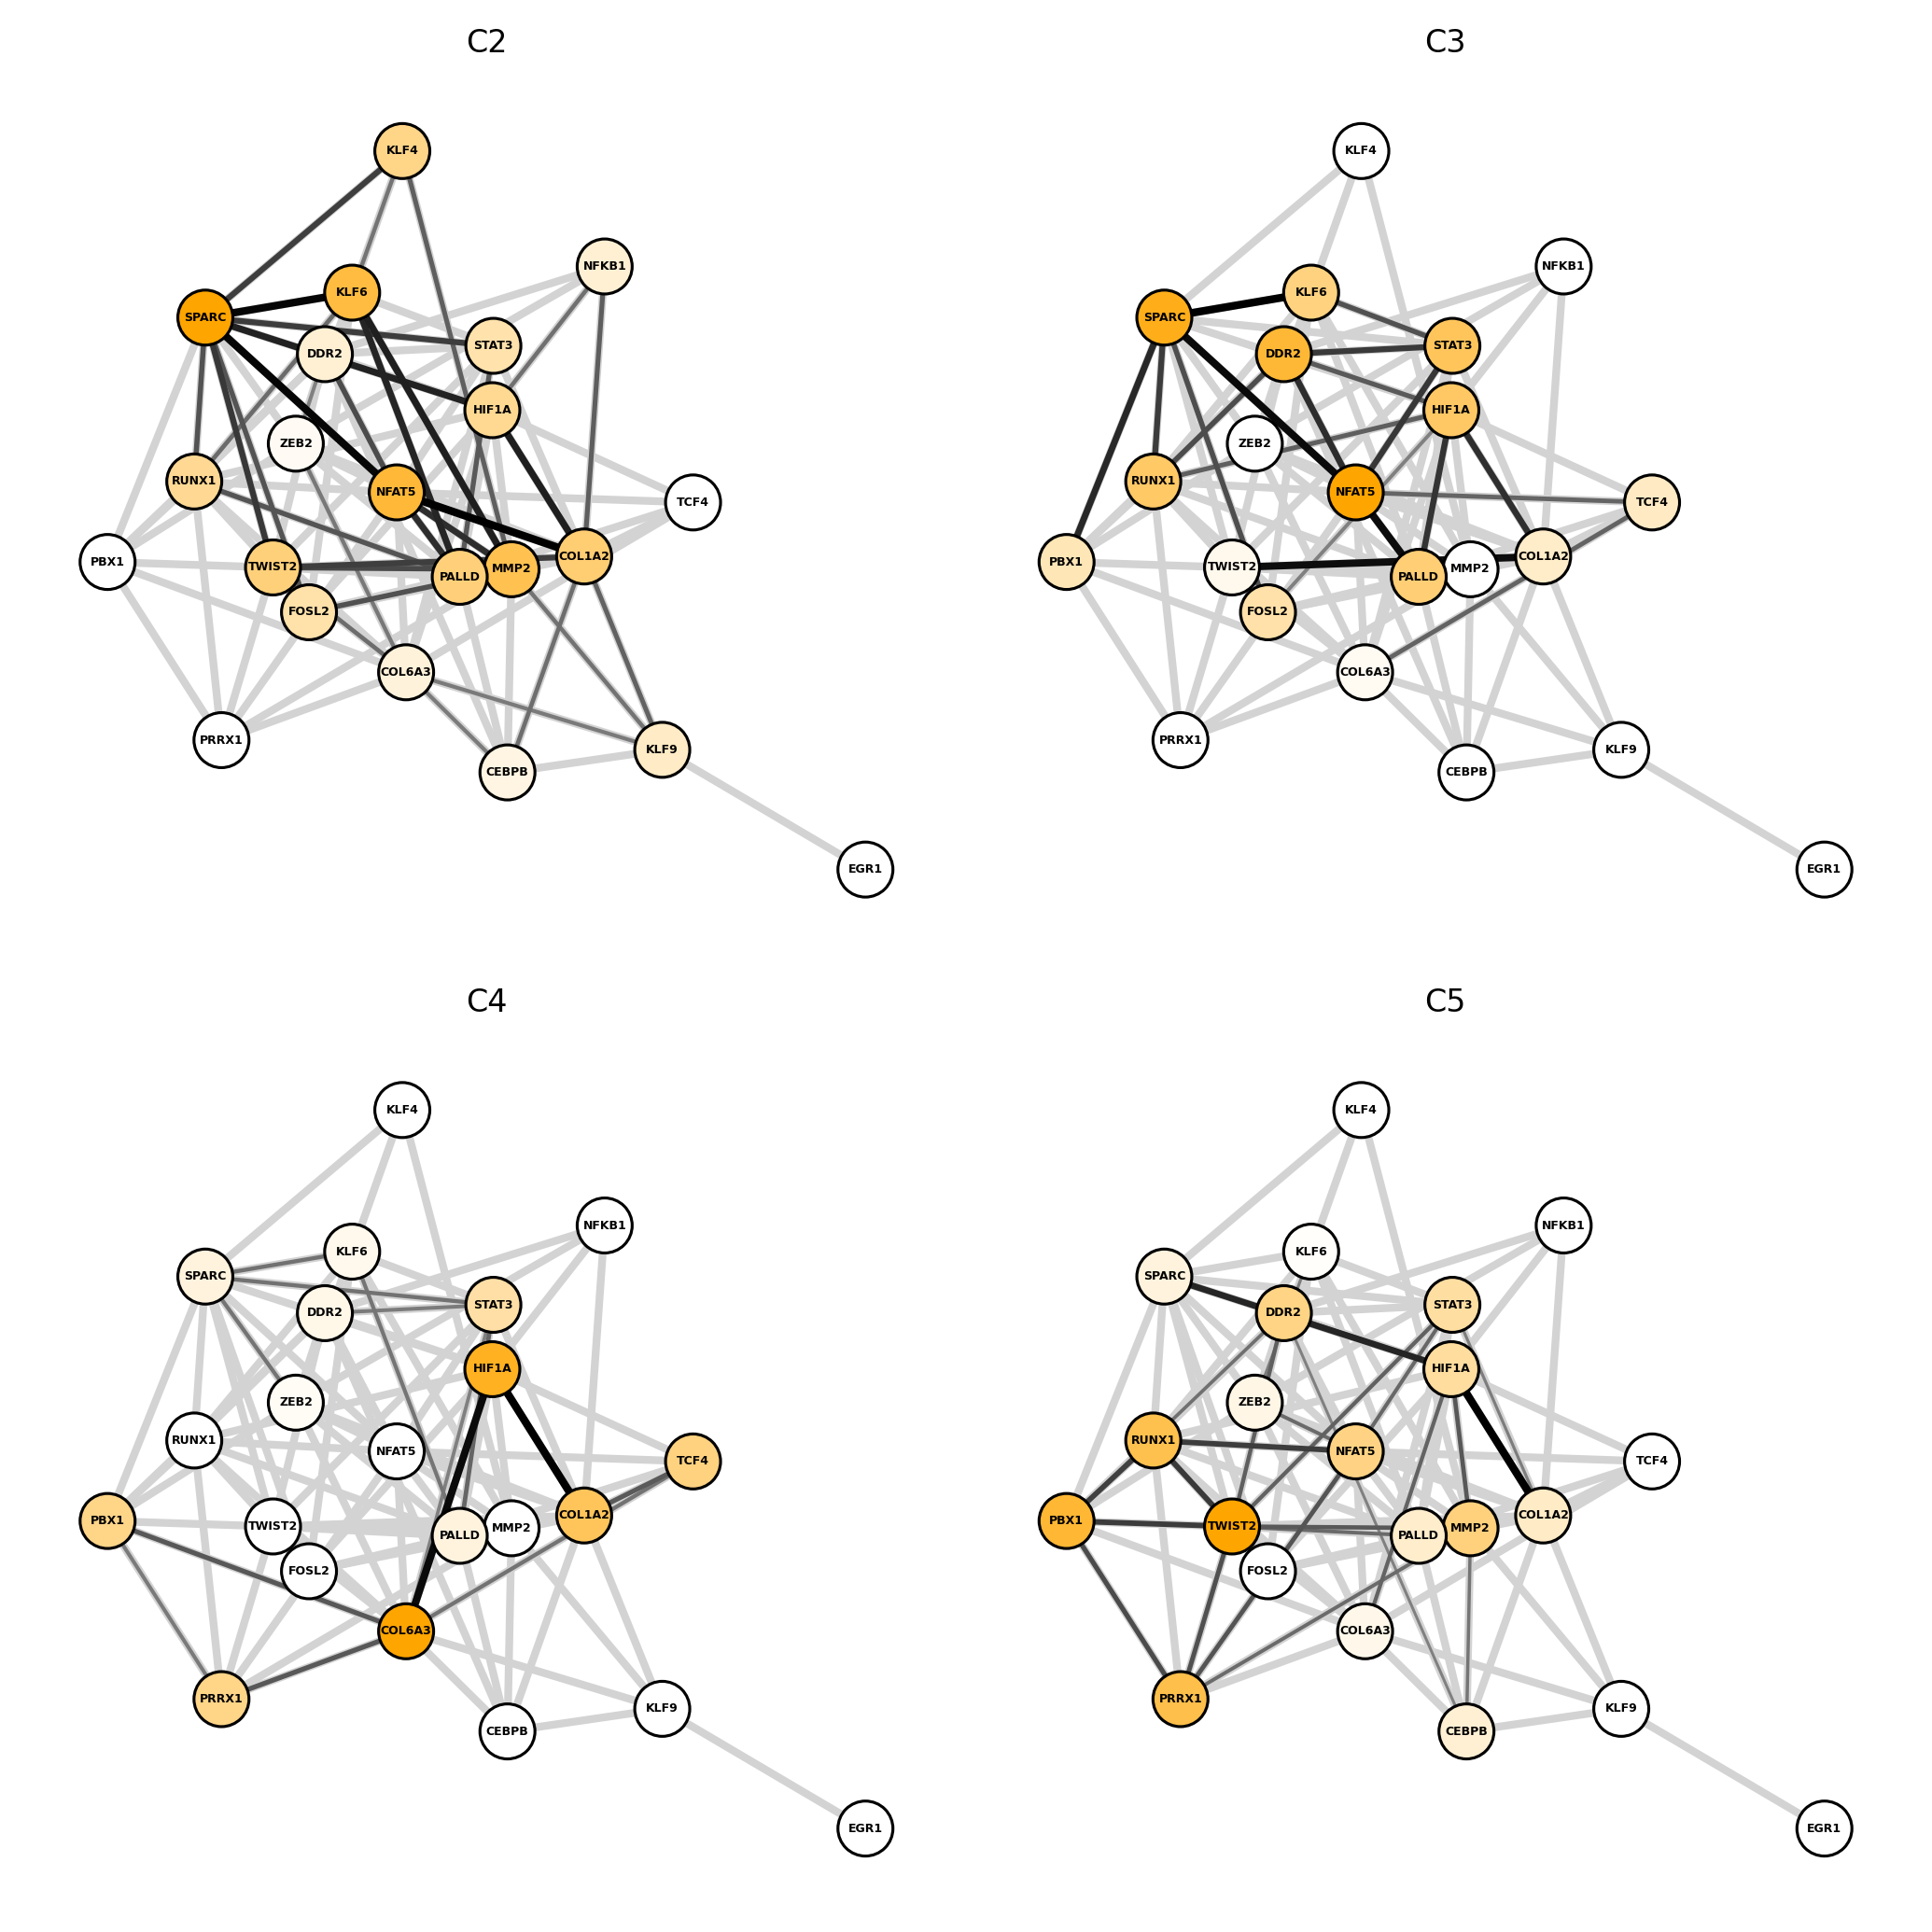

In [22]:
def make_bright_reds_colormap():
    return LinearSegmentedColormap.from_list('lightgrey_black', ['w', 'orange'])

def make_lightgrey_black_colormap():
    return LinearSegmentedColormap.from_list('lightgrey_black', ['grey', 'black'])

def compute_node_values(H, edge_attr):
    ec = nx.eigenvector_centrality(H, max_iter=1000, weight=edge_attr)
    node_values = np.array([ec[n] for n in H.nodes()])
    vmin, vmax = node_values.min(), node_values.max()
    return node_values, vmin, vmax

def draw_edges(H, pos, edge_attr, ax, width_scale=2.0):
    # Background edges
    nx.draw_networkx_edges(
        H, pos,
        edgelist=list(H.edges()),
        edge_color='lightgrey',
        width=2,
        arrows=False,
        ax=ax
    )
    # Foreground edges with weights
    edges_with_weight = [(e, H.edges[e][edge_attr]) for e in H.edges() if H.edges[e][edge_attr] > 0]
    if edges_with_weight:
        edges_with_weight = sorted(edges_with_weight, key=lambda x: x[1])
        edgelist, edgeweights = zip(*edges_with_weight)
        edge_cmap = make_lightgrey_black_colormap()
        k = width_scale / max(edgeweights)
        edgewidths = [k * w for w in edgeweights]
        nx.draw_networkx_edges(
            H, pos,
            edgelist=edgelist,
            edge_color=edgewidths,
            width=edgewidths,
            edge_cmap=edge_cmap,
            alpha=1.0,
            arrows=False,
            ax=ax,
        )

def draw_nodes_and_labels(H, pos, node_values, vmin, vmax, ax, cluster):
    node_cmap = make_bright_reds_colormap()
    nx.draw_networkx_nodes(
        H, pos,
        node_color=node_values,
        node_size=200,
        cmap=node_cmap,
        edgecolors='black',
        linewidths=0.75,
        vmin=vmin,
        vmax=vmax,
        ax=ax,
    )
    nx.draw_networkx_labels(
        H, pos, 
        font_size=3,
        font_weight='bold',
        ax=ax,
    )
    ax.set_title(f"{cluster}", fontsize=8)
    ax.axis('off')

def plot_clusters_panel(H, pos, clusters=['C2', 'C3', 'C4', 'C5']):
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(2, 2, figsize=(7, 7))
    axes = axes.ravel()
    for i, cluster in enumerate(clusters):
        edge_attr = f'MI_{cluster}'
        node_values, vmin, vmax = compute_node_values(H, edge_attr)
        draw_edges(H, pos, edge_attr, axes[i])
        draw_nodes_and_labels(H, pos, node_values, vmin, vmax, axes[i], cluster)
    plt.tight_layout()
    plt.show()


plot_clusters_panel(H, pos, clusters=['C2', 'C3', 'C4', 'C5'])

In [23]:
def add_group_averages_to_graph(H, group1=('C2', 'C3'), group2=('C4', 'C5')):
    """
    Adds mean node and edge attributes for group1 and group2 to the graph H.
    """
    g1_label = ''.join(group1)
    g2_label = ''.join(group2)

    # Nodes
    for n in H.nodes():
        vals1 = [H.nodes[n][f'mean_{g}'] for g in group1 if f'mean_{g}' in H.nodes[n]]
        vals2 = [H.nodes[n][f'mean_{g}'] for g in group2 if f'mean_{g}' in H.nodes[n]]
        H.nodes[n][f'mean_{g1_label}'] = np.mean(vals1) if vals1 else 0
        H.nodes[n][f'mean_{g2_label}'] = np.mean(vals2) if vals2 else 0

    # Edges
    for e in H.edges():
        vals1 = [H.edges[e].get(f'MI_{g}', 0) for g in group1]
        vals2 = [H.edges[e].get(f'MI_{g}', 0) for g in group2]
        H.edges[e][f'MI_{g1_label}'] = np.mean(vals1) if vals1 else 0
        H.edges[e][f'MI_{g2_label}'] = np.mean(vals2) if vals2 else 0

    return f'{g1_label}', f'{g2_label}'

def plot_group_averages_panel(H, pos, group1_label, group2_label):
    """
    Plots two panels for the averaged groups (group1_label and group2_label).
    """
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for i, label in enumerate([group1_label, group2_label]):
        edge_attr = f'MI_{label}'
        node_values, vmin, vmax = compute_node_values(H, edge_attr)
        draw_edges(H, pos, edge_attr, axes[i])
        draw_nodes_and_labels(H, pos, node_values, vmin, vmax, axes[i], f"Mean {label}")
    plt.tight_layout()
    plt.show()


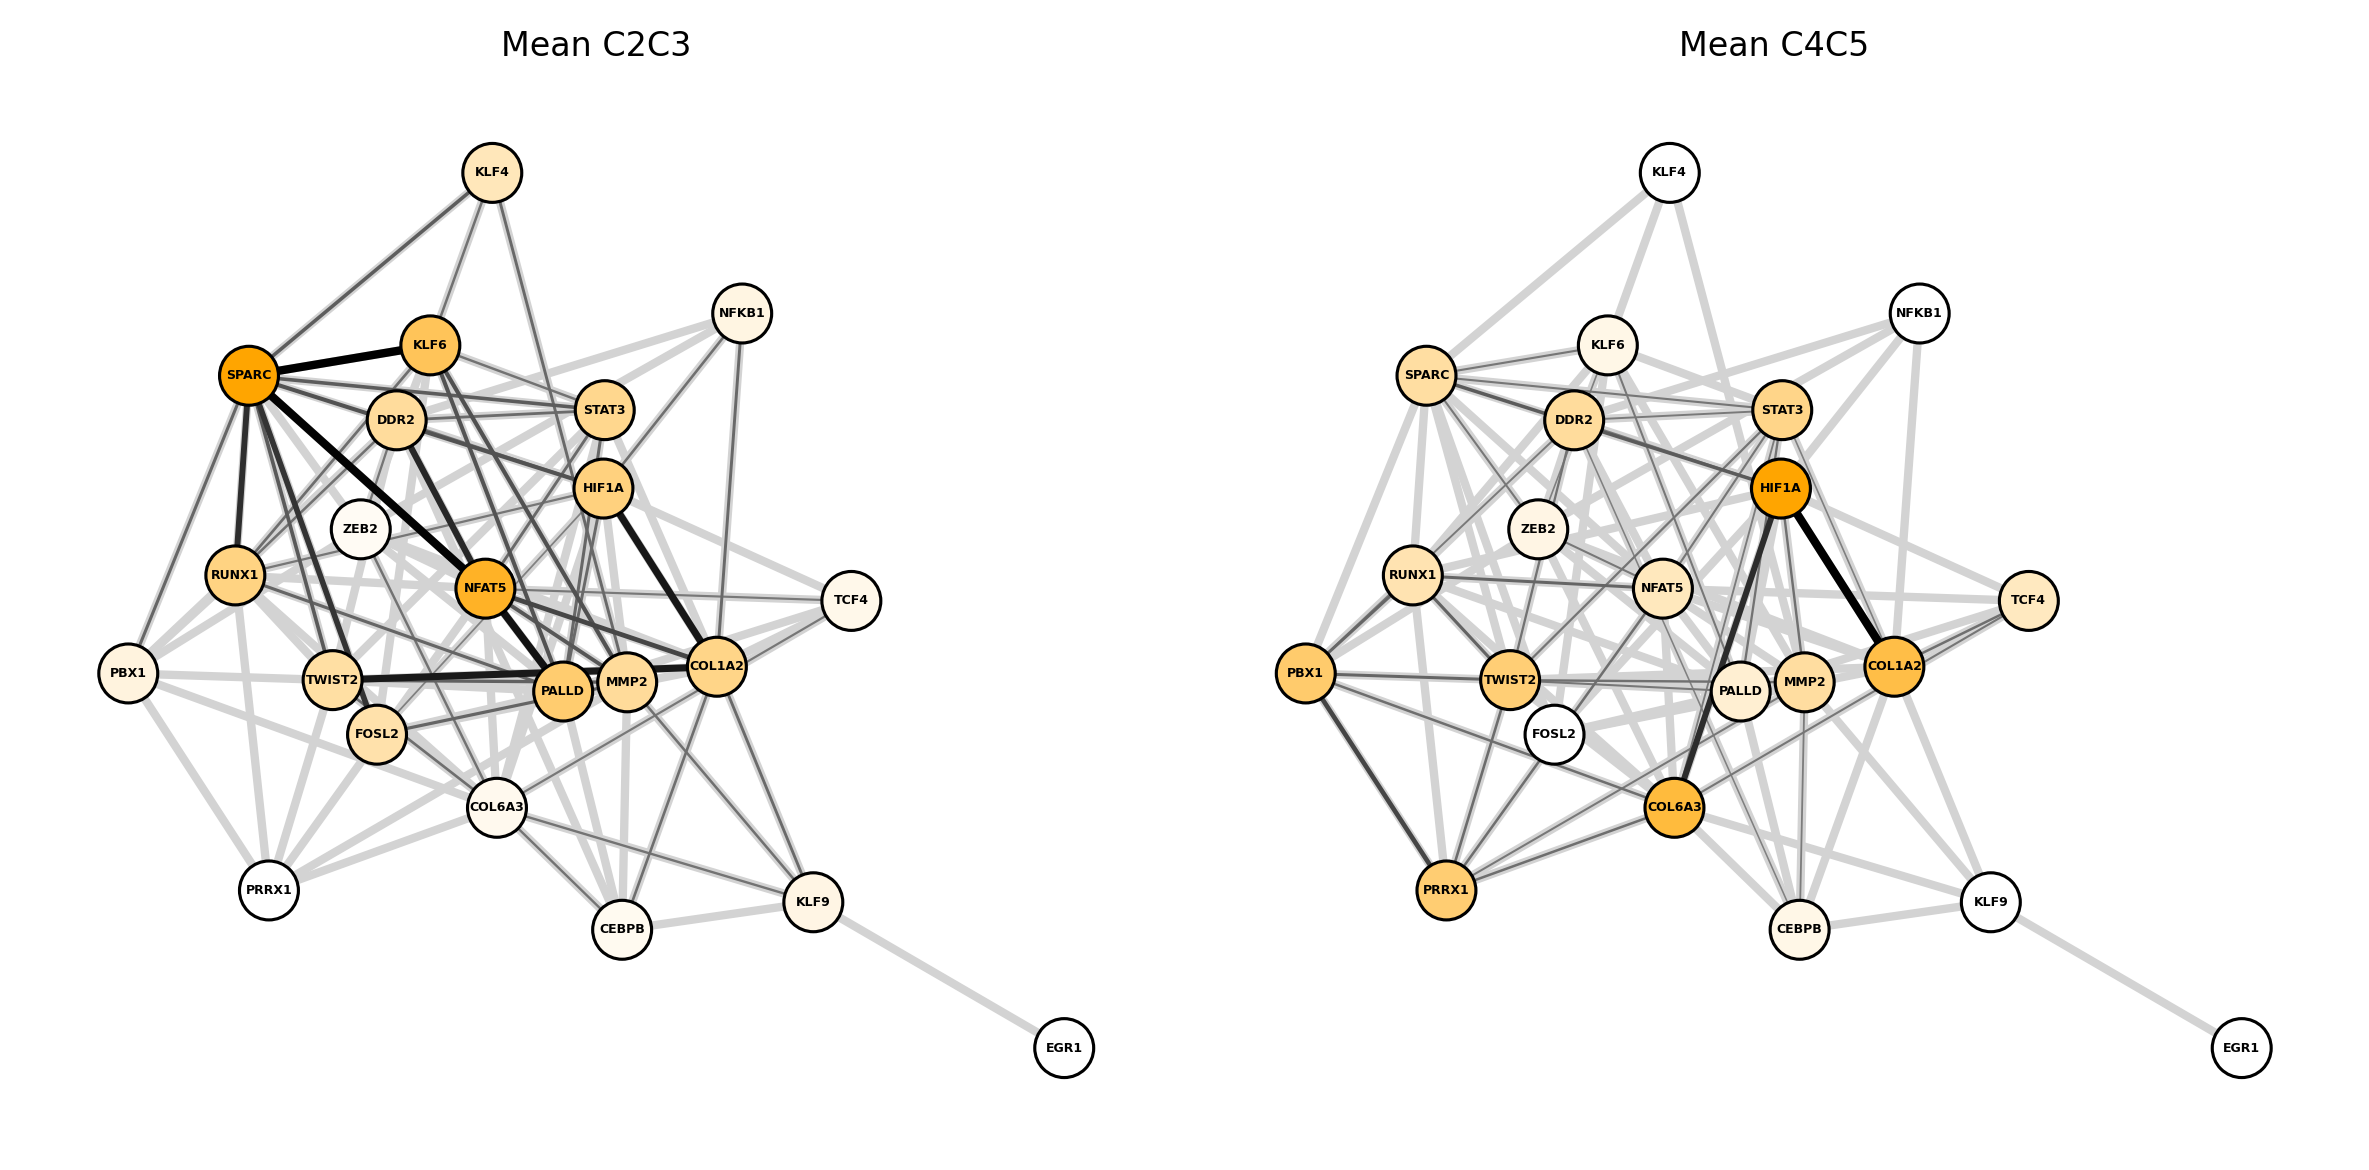

In [24]:
# Add group averages to graph
g1_label, g2_label = add_group_averages_to_graph(H, group1=('C2','C3'), group2=('C4','C5'))

# Plot the two panels (mean of C2/C3 and mean of C4/C5)
plot_group_averages_panel(H, pos, g1_label, g2_label)

In [25]:
# Global distances

In [26]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Endothelial

In [ ]:
H, pos = get_top_degree_subgraph_and_layout(
    G, mdf, source='panglao', category='endothelial', top_pct=0.10
)
plot_graph_plain(H, pos)
plot_clusters_panel(H, pos, clusters=['C2', 'C3', 'C4', 'C5'])

In [ ]:
H, pos = get_top_degree_subgraph_and_layout(
    G, mdf, source='panglao', category='hematopoietic', top_pct=0.15
)
plot_graph_plain(H, pos)
plot_clusters_panel(H, pos, clusters=['C2', 'C3', 'C4', 'C5'])

In [ ]:
break

# Archive 

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.figure(figsize=(30, 30))
fig, axes = plt.subplots(2, 2)
axes = axes.ravel()

for i, cluster in enumerate(['C2', 'C3', 'C4', 'C5']):
    node_attr = f'mean_{cluster}'
    edge_attr = f'MI_{cluster}'
    
    # Custom colormap
    reds = plt.cm.get_cmap('Reds', 256)
    new_colors = reds(np.linspace(0, 1, 256))
    new_colors[-1] = [1.0, 0.0, 0.0, 1.0]
    bright_reds = mcolors.ListedColormap(new_colors)
    node_cmap = bright_reds
    
    # Node values for color
    node_values = np.array([H.nodes[n][node_attr] for n in H.nodes()])
    vmin, vmax = node_values.min(), node_values.max()
    
    # Draw all edges as thin grey lines
    nx.draw_networkx_edges(
        H, pos,
        edgelist=list(H.edges()),
        edge_color='lightgrey',
        width=2,
        arrows=False,
        ax=axes[i]
    )
    
    # Extract edges and weights for foreground plotting
    edges_with_weight = [(e, H.edges[e][edge_attr]) for e in H.edges() if H.edges[e][edge_attr] > 0]
    
    # Define custom colormap
    lightgrey_black = LinearSegmentedColormap.from_list('lightgrey_black', ['grey', 'black'])
    
    if edges_with_weight:
        # Sort edges by weight (low to high)
        edges_with_weight = sorted(edges_with_weight, key=lambda x: x[1])
        edgelist, edgeweights = zip(*edges_with_weight)
        k = 2.0 / max(edgeweights)  # Scale max width to ~10
        edgewidths = [k * w for w in edgeweights]
        nx.draw_networkx_edges(
            H, pos,
            edgelist=edgelist,
            edge_color=edgewidths,
            width=edgewidths,
            edge_cmap=lightgrey_black,
            alpha=1.0,
            arrows=False,
            ax=axes[i],
        )
    
    # Node centrality for color
    ec = nx.eigenvector_centrality(H, max_iter=1000, weight=edge_attr)
    node_values = np.array([ec[n] for n in H.nodes()])
    vmin, vmax = node_values.min(), node_values.max()
    
    # Draw nodes
    nx.draw_networkx_nodes(
        H, pos,
        node_color=node_values,
        node_size=200,
        cmap=node_cmap,
        edgecolors='black',
        linewidths=0.75,
        vmin=vmin,
        vmax=vmax,
        ax=axes[i],
    )
    
    # Draw labels
    nx.draw_networkx_labels(
        H, 
        pos, 
        font_size=3,
        font_weight='bold',
        ax=axes[i],
    )
    
    axes[i].set_title(f"{cluster}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

# Combine node attributes for mean
for n in H.nodes():
    H.nodes[n]['mean_C2C3'] = 0.5 * (H.nodes[n]['mean_C2'] + H.nodes[n]['mean_C3'])
    H.nodes[n]['mean_C4C5'] = 0.5 * (H.nodes[n]['mean_C4'] + H.nodes[n]['mean_C5'])

# Combine edge attributes for mean
for e in H.edges():
    H.edges[e]['MI_C2C3'] = 0.5 * (H.edges[e].get('MI_C2', 0) + H.edges[e].get('MI_C3', 0))
    H.edges[e]['MI_C4C5'] = 0.5 * (H.edges[e].get('MI_C4', 0) + H.edges[e].get('MI_C5', 0))

# Custom colormap for nodes (bright reds)
reds = plt.cm.get_cmap('Reds', 256)
new_colors = reds(np.linspace(0, 1, 256))
new_colors[-1] = [1.0, 0.0, 0.0, 1.0]
bright_reds = ListedColormap(new_colors)

# Custom colormap for edges (lightgrey to black)
lightgrey_black = LinearSegmentedColormap.from_list('lightgrey_black', ['grey', 'black'])

# Set up subplots
plt.rcParams['figure.dpi'] = 200
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for idx, (cluster, node_attr, edge_attr, ax) in enumerate([
    ('C2/C3', 'mean_C2C3', 'MI_C2C3', axs[0]),
    ('C4/C5', 'mean_C4C5', 'MI_C4C5', axs[1])
]):
    # Node values for color
    node_values = np.array([H.nodes[n][node_attr] for n in H.nodes()])
    vmin, vmax = node_values.min(), node_values.max()

    # Draw all edges as thin grey lines
    nx.draw_networkx_edges(
        H, pos,
        edgelist=list(H.edges()),
        edge_color='lightgrey',
        width=3,
        arrows=False,
        ax=ax
    )

    # Extract edges and weights for foreground plotting
    edges_with_weight = [(e, H.edges[e][edge_attr]) for e in H.edges() if H.edges[e][edge_attr] > 0]
    if edges_with_weight:
        # Sort edges by weight (low to high)
        edges_with_weight = sorted(edges_with_weight, key=lambda x: x[1])
        edgelist, edgeweights = zip(*edges_with_weight)
        k = 3.0 / max(edgeweights)  # Scale max width to ~10
        edgewidths = [k * w for w in edgeweights]
        nx.draw_networkx_edges(
            H, pos,
            edgelist=edgelist,
            edge_color=edgewidths,
            width=edgewidths,
            edge_cmap=lightgrey_black,
            alpha=1.0,
            arrows=False,
            ax=ax
        )

    # Node centrality for color
    ec = nx.eigenvector_centrality(H, max_iter=1000, weight=edge_attr)
    node_values = np.array([ec[n] for n in H.nodes()])
    vmin, vmax = node_values.min(), node_values.max()

    nx.draw_networkx_nodes(
        H, pos,
        node_color=node_values,
        node_size=500,
        cmap=bright_reds,
        edgecolors='black',
        linewidths=1,
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )

    nx.draw_networkx_labels(H, pos, font_size=4.5, font_weight='bold', ax=ax)
    ax.set_title(f"Mean Cluster {cluster}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
break

# graph distances

In [ ]:
cluster_metrics = []

for name, sg in subgraphs.items():
    num_nodes = sg.number_of_nodes()
    num_edges = sg.number_of_edges()
    
    if num_nodes == 0: # Handle empty clusters
        density = 0
        avg_clustering = 0
        # Other metrics might be 0 or undefined
    else:
        density = nx.density(sg)
        avg_clustering = nx.average_clustering(sg) if num_nodes > 0 else 0
    
    # Add more metrics as needed:
    # avg_degree = sum(dict(sg.degree()).values()) / num_nodes if num_nodes > 0 else 0
    # Example: Average of a node attribute 'some_value'
    # avg_node_attr = sum(d['some_value'] for n, d in sg.nodes(data=True)) / num_nodes if num_nodes > 0 else 0
    
    metrics = {
        'Cluster': name,
        'MI_Score': mi_scores.get(name), # Get the pre-calculated MI score
        'Num_Nodes': num_nodes,
        'Num_Edges': num_edges,
        'Density': density,
        'Avg_Clustering_Coeff': avg_clustering,
        # 'Avg_Degree': avg_degree,
        # 'Avg_Custom_Node_Attr': avg_node_attr,
    }
    cluster_metrics.append(metrics)

# Create a Pandas DataFrame
df_comparison = pd.DataFrame(cluster_metrics)

In [ ]:
break

In [ ]:
break

In [ ]:
break